# Transformer Model — MITSUI Commodity Prediction Challenge
### Lag-1 (1-day-ahead) Return Prediction
Pipeline aligned with `data_cleaning_v2.ipynb` outputs.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Load Data
These CSVs are the **already-cleaned & engineered** outputs of `data_cleaning_v2.ipynb`.
- X already contains lag features, rolling stats, return/momentum, cross-market spreads,
  label-lag features, **and** `_observed` flag columns (one per target).
- Y NaNs were filled with 0 (market-closed days) during cleaning.
- The first 20 warm-up rows were already dropped from training during cleaning.

In [3]:
X_train = pd.read_csv('X_train_lag1.csv')
Y_train = pd.read_csv('Y_train_lag1.csv')
X_val   = pd.read_csv('X_val_lag1.csv')
Y_val   = pd.read_csv('Y_val_lag1.csv')
obs_val = pd.read_csv('obs_val_lag1.csv')

print(f'X_train: {X_train.shape}, Y_train: {Y_train.shape}')
print(f'X_val:   {X_val.shape},   Y_val:   {Y_val.shape}')
print(f'obs_val: {obs_val.shape}')

observed_flag_cols = [c for c in X_train.columns if c.endswith('_observed')]
print(f'\nObserved-flag cols in X: {len(observed_flag_cols)} (e.g. {observed_flag_cols[:3]})')
print(f'All other feature cols:  {X_train.shape[1] - len(observed_flag_cols)}')

X_train: (1549, 3280), Y_train: (1549, 106)
X_val:   (392, 3280),   Y_val:   (392, 106)
obs_val: (392, 106)

Observed-flag cols in X: 424 (e.g. ['target_0_observed', 'target_1_observed', 'target_2_observed'])
All other feature cols:  2856


## 3. Temporal Encoding (Day-of-Week)
`dateid` was dropped by the cleaning pipeline, so we reconstruct cyclical
day-of-week features from a business-day range anchored at the known
train/val split (~80/20 time-based cut used in cleaning).

In [5]:
def add_dow_features(X_df, start_date):
    """Append sin/cos cyclical day-of-week columns."""
    
    date_cols = [c for c in X_df.columns if 'date' in c.lower()]
    if date_cols:
        dti = pd.DatetimeIndex(pd.to_datetime(X_df[date_cols[0]]))
    else:
        dti = pd.bdate_range(start=start_date, periods=len(X_df))
    dow = dti.dayofweek.to_numpy().astype(float)  # 0=Mon .. 4=Fri
    X_df = X_df.copy()
    X_df['dow_sin'] = np.sin(2 * np.pi * dow / 5)
    X_df['dow_cos'] = np.cos(2 * np.pi * dow / 5)
    return X_df

X_train = add_dow_features(X_train, start_date='2012-01-02')
X_val   = add_dow_features(X_val,   start_date='2021-01-04')
print('Day-of-week features added.')
print(f'X_train shape after DOW: {X_train.shape}')

Day-of-week features added.
X_train shape after DOW: (1549, 3282)


## 4. Preprocessing: Scale X, Standardise Y
Per README and `data_cleaning_v2.ipynb`:
- X: `fillna(0)` (NaNs are lag/rolling warm-up at series start), then `StandardScaler`.
  **Note:** `_observed` flag columns are kept in X — they are intentional input signals.
- Y: standardise per target (mean/std from train); inverse-transform predictions later.
- PCA to 50 components after scaling (README: 'attention gets noisy with many features').

In [6]:

x_scaler = StandardScaler()
X_tr_scaled = x_scaler.fit_transform(X_train.fillna(0))   # fit on train only
X_vl_scaled = x_scaler.transform(X_val.fillna(0))

#PCA: 50 components (README recommendation)
pca = PCA(n_components=50, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_scaled)
X_vl_pca = pca.transform(X_vl_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}')
print(f'X_tr_pca: {X_tr_pca.shape}')

#Standardise Y per target
target_cols = Y_train.columns.tolist()
y_means = Y_train[target_cols].mean()
y_stds  = Y_train[target_cols].std().replace(0, 1)

Y_tr_scaled = ((Y_train[target_cols] - y_means) / y_stds).values.astype(np.float32)
Y_vl_scaled = ((Y_val[target_cols]   - y_means) / y_stds).values.astype(np.float32)
print(f'Y_tr_scaled: {Y_tr_scaled.shape}')

PCA explained variance: 0.886
X_tr_pca: (1549, 50)
Y_tr_scaled: (1549, 106)


## 5. Build Rolling-Window Sequences (T = 20)
Transformer input shape: `(batch, seq_len, n_features)`.
Each sample is a rolling window of the last **T = 20** trading days.

**Warm-up note:** `data_cleaning_v2.ipynb` already dropped the first 20
rows from training (lag/rolling warm-up). The sequence builder drops a
further T rows as it needs T history rows to form the first window — this
is expected and unavoidable.

In [7]:
T = 20

def make_sequences(X_arr, Y_arr, seq_len):
    """
    Returns:
      X_seq : (N-seq_len, seq_len, n_features)  — rolling windows
      Y_seq : (N-seq_len, n_targets)            — label at day i (next day after window)
    """
    xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        xs.append(X_arr[i - seq_len : i])   
        ys.append(Y_arr[i])                 
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train_seq, Y_train_seq = make_sequences(X_tr_pca, Y_tr_scaled, T)
X_val_seq,   Y_val_seq   = make_sequences(X_vl_pca, Y_vl_scaled, T)


obs_val_aligned    = obs_val.iloc[T:].reset_index(drop=True)
Y_val_raw_aligned  = Y_val[target_cols].iloc[T:].reset_index(drop=True)

print(f'Train sequences : {X_train_seq.shape},  labels: {Y_train_seq.shape}')
print(f'Val   sequences : {X_val_seq.shape},    labels: {Y_val_seq.shape}')

Train sequences : (1529, 20, 50),  labels: (1529, 106)
Val   sequences : (372, 20, 50),    labels: (372, 106)


## 6. PyTorch Dataset & DataLoader

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

BATCH_SIZE = 64
train_ds = TimeSeriesDataset(X_train_seq, Y_train_seq)
val_ds   = TimeSeriesDataset(X_val_seq,   Y_val_seq)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)},  Val batches: {len(val_loader)}')

Train batches: 23,  Val batches: 6


## 7. Sinusoidal Positional Encoding
Classic Vaswani et al. (2017) encoding — required by README:
> 'Add positional encoding (sinusoidal or learned) — without it the model has no sense of time order'

In [9]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Adds a fixed sinusoidal position signal to token embeddings.
    Shape in/out: (batch, seq_len, d_model)
    """
    def __init__(self, d_model: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

## 8. Transformer Model
Encoder-only architecture:
```
Input (batch, T, 50)  →  Linear projection  →  Positional Encoding
  →  N × TransformerEncoderLayer (Pre-LN, multi-head attention + FFN)
  →  Mean pooling over sequence
  →  MLP head  →  (batch, n_targets)
```

In [10]:
class CommodityTransformer(nn.Module):
    def __init__(
        self,
        n_features: int,
        n_targets: int,
        d_model: int = 128,
        nhead: int = 4,
        num_encoder_layers: int = 3,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
        max_seq_len: int = 500,
    ):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = SinusoidalPositionalEncoding(d_model, max_len=max_seq_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   
            norm_first=True,    
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_targets),
        )

    def forward(self, x):
        x = self.input_proj(x)   
        x = self.pos_enc(x)      
        x = self.encoder(x)      
        x = x.mean(dim=1)        
        return self.head(x)      


n_features = X_train_seq.shape[2]   
n_targets  = Y_train_seq.shape[1]   

model = CommodityTransformer(
    n_features=n_features,
    n_targets=n_targets,
    d_model=128,
    nhead=4,
    num_encoder_layers=3,
    dim_feedforward=256,
    dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 434,154
CommodityTransformer(
  (input_proj): Linear(in_features=50, out_features=128, bias=True)
  (pos_enc): SinusoidalPositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
   

## 9. Training
- **Loss**: MSE on standardised Y
- **Optimiser**: AdamW + CosineAnnealingLR
- **Gradient clipping** (max norm 1.0) for stability
- **Early stopping** (patience = 5 epochs on val MSE)

In [11]:
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 5

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float('inf')
best_state    = None
patience_ctr  = 0
history       = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_ds)

    scheduler.step()
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f'Epoch {epoch:3d}/{EPOCHS} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')

    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping triggered at epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nBest val MSE (standardised): {best_val_loss:.6f}')

Epoch   1/30 | Train MSE: 1.086175 | Val MSE: 0.858363
Epoch   2/30 | Train MSE: 0.942796 | Val MSE: 0.839813
Epoch   3/30 | Train MSE: 0.974427 | Val MSE: 0.840312
Epoch   4/30 | Train MSE: 0.973269 | Val MSE: 0.839287
Epoch   5/30 | Train MSE: 0.971200 | Val MSE: 0.838121
Epoch   6/30 | Train MSE: 0.929668 | Val MSE: 0.837809
Epoch   7/30 | Train MSE: 0.967484 | Val MSE: 0.838498
Epoch   8/30 | Train MSE: 0.957305 | Val MSE: 0.837942
Epoch   9/30 | Train MSE: 0.956232 | Val MSE: 0.838053
Epoch  10/30 | Train MSE: 0.952023 | Val MSE: 0.837996
Epoch  11/30 | Train MSE: 0.959312 | Val MSE: 0.838495
Early stopping triggered at epoch 11

Best val MSE (standardised): 0.837809


## 10. Validation Metrics — Masked by `obs_val`
Per README and `data_cleaning_v2.ipynb`:
> *'Always filter by the mask when computing validation metrics,
otherwise you're scoring the model against filled zeros.'*

Each target has its own `<target>_observed` mask because different
markets have different holiday calendars.

In [12]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


model.eval()
all_preds_scaled = []
with torch.no_grad():
    for xb, _ in val_loader:
        all_preds_scaled.append(model(xb.to(device)).cpu().numpy())

preds_scaled = np.vstack(all_preds_scaled)   # (N_val_seq, n_targets)


preds_df = pd.DataFrame(
    preds_scaled * y_stds.values + y_means.values,
    columns=target_cols
)


results = []
for target in target_cols:
    obs_col = f'{target}_observed'
    if obs_col not in obs_val_aligned.columns:
        continue
    mask = obs_val_aligned[obs_col].astype(bool)
    if mask.sum() < 2:
        continue
    y_true = Y_val_raw_aligned.loc[mask, target].values
    y_pred = preds_df.loc[mask, target].values
    mse       = mean_squared_error(y_true, y_pred)
    corr, _   = pearsonr(y_true, y_pred)
    results.append({'target': target, 'MSE': mse, 'Pearson_r': corr})

results_df = pd.DataFrame(results)
print('=== Validation Results (observed days only) ===')
print(results_df[['MSE', 'Pearson_r']].describe().round(6))
print(f'\nMean MSE:       {results_df["MSE"].mean():.6f}')
print(f'Mean Pearson r: {results_df["Pearson_r"].mean():.4f}')

=== Validation Results (observed days only) ===
              MSE   Pearson_r
count  106.000000  106.000000
mean     0.000354   -0.000644
std      0.000278    0.038536
min      0.000100   -0.093384
25%      0.000174   -0.027390
50%      0.000267    0.004452
75%      0.000447    0.027180
max      0.001892    0.084090

Mean MSE:       0.000354
Mean Pearson r: -0.0006


## 11. Save Outputs

In [13]:
torch.save(model.state_dict(), 'transformer_best.pt')
print('Model saved -> transformer_best.pt')


preds_df.to_csv('transformer_val_preds.csv', index=False)
print('Predictions saved -> transformer_val_preds.csv')


results_df.to_csv('transformer_val_metrics.csv', index=False)
print('Metrics saved -> transformer_val_metrics.csv')

Model saved -> transformer_best.pt
Predictions saved -> transformer_val_preds.csv
Metrics saved -> transformer_val_metrics.csv


## 12. Training Curve

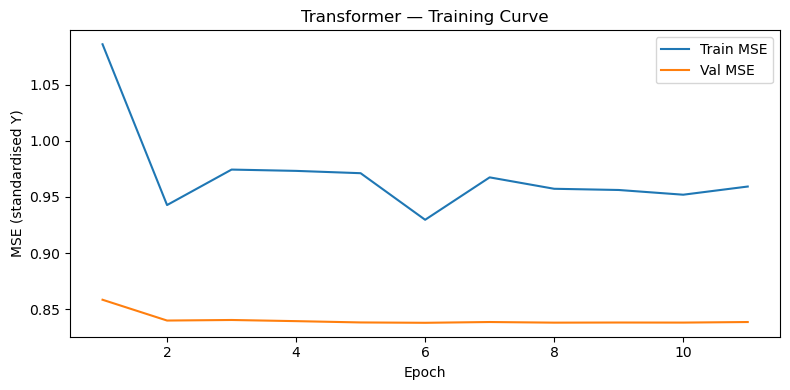

Saved -> transformer_training_curve.png


In [14]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_df['epoch'], hist_df['train_loss'], label='Train MSE')
ax.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (standardised Y)')
ax.set_title('Transformer — Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('transformer_training_curve.png', dpi=150)
plt.show()
print('Saved -> transformer_training_curve.png')

## 13. Scale-Up Note
Once lag-1 is validated, scaling to all 424 targets requires zero pipeline changes.
Simply swap the target CSVs as noted in `data_cleaning_v2.ipynb`:
```python
# Replace:
Y_train = pd.read_csv('Y_train_lag1.csv')   # 106 targets
Y_val   = pd.read_csv('Y_val_lag1.csv')
# With:
Y_train = pd.read_csv('Y_train.csv')        # 424 targets
Y_val   = pd.read_csv('Y_val.csv')
# X stays identical — all engineered features are shared across all targets.
```